In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")


All libraries loaded successfully!
Pandas version: 2.0.3


In [24]:
import os

# Load both datasets
df_industry = pd.read_csv('../data/raw/labour_force_industry.csv', encoding='latin-1')
df_province = pd.read_csv('../data/raw/unemployment_province.csv', encoding='latin-1')

print("=== INDUSTRY TABLE ===")
print(f"Shape: {df_industry.shape}")
print(df_industry.columns.tolist())
print(df_industry.head(3))

print("\n=== PROVINCE TABLE ===")
print(f"Shape: {df_province.shape}")
print(df_province.columns.tolist())
print(df_province.head(3))

C:\Users\nunjp\AppData\Local\Temp\ipykernel_2772\1792060818.py:5: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_province = pd.read_csv('../data/raw/unemployment_province.csv', encoding='latin-1')


=== INDUSTRY TABLE ===
Shape: (1043592, 18)
['ï»¿"REF_DATE"', 'GEO', 'DGUID', 'Labour force characteristics', 'North American Industry Classification System (NAICS)', 'Gender', 'Age group', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']
   ï»¿"REF_DATE"     GEO           DGUID Labour force characteristics  \
0           1976  Canada  2021A000011124                 Labour force   
1           1976  Canada  2021A000011124                 Labour force   
2           1976  Canada  2021A000011124                 Labour force   

  North American Industry Classification System (NAICS)          Gender  \
0                              Total, all industries     Total - Gender   
1                              Total, all industries     Total - Gender   
2                              Total, all industries     Total - Gender   

           Age group                   UOM  UOM_ID SCALAR_FACTOR  SCALAR_ID  \
0  15 years

In [25]:
# Fix the messy first column name (BOM encoding issue)
df_industry.columns = df_industry.columns.str.replace('ï»¿"', '').str.replace('"', '').str.strip()
df_province.columns = df_province.columns.str.replace('ï»¿"', '').str.replace('"', '').str.strip()

# Rename columns for easier use
df_industry.rename(columns={
    'REF_DATE': 'year',
    'GEO': 'geography',
    'Labour force characteristics': 'characteristic',
    'North American Industry Classification System (NAICS)': 'industry',
    'Gender': 'gender',
    'Age group': 'age_group',
    'VALUE': 'value'
}, inplace=True)

df_province.rename(columns={
    'REF_DATE': 'year',
    'GEO': 'geography',
    'Labour force characteristics': 'characteristic',
    'VALUE': 'value'
}, inplace=True)

# Drop rows with no value
df_industry.dropna(subset=['value'], inplace=True)
df_province.dropna(subset=['value'], inplace=True)

print("Cleaned industry shape:", df_industry.shape)
print("Cleaned province shape:", df_province.shape)
print("\nUnique characteristics:", df_industry['characteristic'].unique())
print("\nUnique geographies (industry):", df_industry['geography'].unique()[:15])

Cleaned industry shape: (741265, 18)
Cleaned province shape: (3963817, 19)

Unique characteristics: ['Labour force' 'Employment' 'Full-time employment' 'Part-time employment'
 'Unemployment' 'Unemployment rate']

Unique geographies (industry): ['Canada' 'Newfoundland and Labrador' 'Prince Edward Island' 'Nova Scotia'
 'New Brunswick' 'Quebec' 'Ontario' 'Manitoba' 'Saskatchewan' 'Alberta'
 'British Columbia']


In [26]:
# Focus: Employment numbers only, all genders, 15+ years
df_employed = df_industry[
    (df_industry['characteristic'] == 'Employment') &
    (df_industry['gender'] == 'Total - Gender') &
    (df_industry['age_group'] == '15 years and over')
].copy()

# Remove national total — keep provinces only
df_employed = df_employed[df_employed['geography'] != 'Canada']

# Keep only key columns
df_employed = df_employed[['year', 'geography', 'industry', 'value']]

print("Employment dataset shape:", df_employed.shape)
print("\nYear range:", df_employed['year'].min(), "to", df_employed['year'].max())
print("\nProvinces:", df_employed['geography'].unique())
print("\nIndustries:", df_employed['industry'].unique())

Employment dataset shape: (12811, 4)

Year range: 1976 to 2025

Provinces: ['Newfoundland and Labrador' 'Prince Edward Island' 'Nova Scotia'
 'New Brunswick' 'Quebec' 'Ontario' 'Manitoba' 'Saskatchewan' 'Alberta'
 'British Columbia']

Industries: ['Total, all industries' 'Goods-producing sector'
 'Agriculture [111-112, 1100, 1151-1152]'
 'Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]'
 'Utilities [22]' 'Construction [23]' 'Manufacturing [31-33]'
 'Services-producing sector' 'Wholesale and retail trade [41, 44-45]'
 'Transportation and warehousing [48-49]'
 'Finance, insurance, real estate, rental and leasing [52, 53]'
 'Professional, scientific and technical services [54]'
 'Business, building and other support services [55, 56]'
 'Educational services [61]' 'Health care and social assistance [62]'
 'Information, culture and recreation [51, 71]'
 'Accommodation and food services [72]'
 'Other services (except public administration) [81]'
 'Public administr

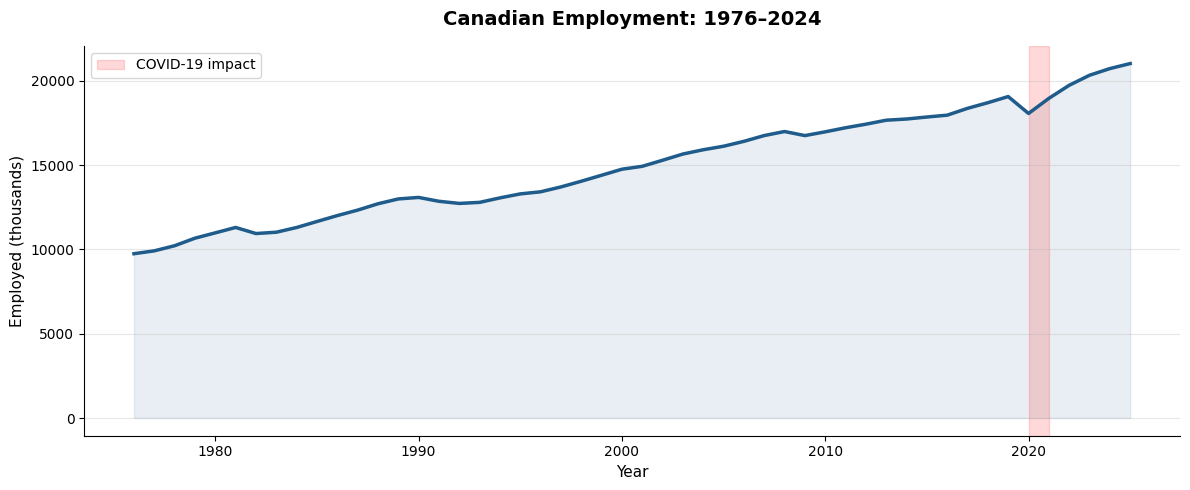

Chart saved!


In [27]:
# National employment over time (use Canada from original df)
df_national = df_industry[
    (df_industry['characteristic'] == 'Employment') &
    (df_industry['gender'] == 'Total - Gender') &
    (df_industry['age_group'] == '15 years and over') &
    (df_industry['geography'] == 'Canada') &
    (df_industry['industry'] == 'Total, all industries')
].copy()

df_national = df_national.sort_values('year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_national['year'], df_national['value'], color='#1F5C8B', linewidth=2.5)
ax.fill_between(df_national['year'], df_national['value'], alpha=0.1, color='#1F5C8B')

# Highlight COVID dip
ax.axvspan(2020, 2021, alpha=0.15, color='red', label='COVID-19 impact')

ax.set_title('Canadian Employment: 1976–2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Employed (thousands)', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../outputs/charts/01_national_employment_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

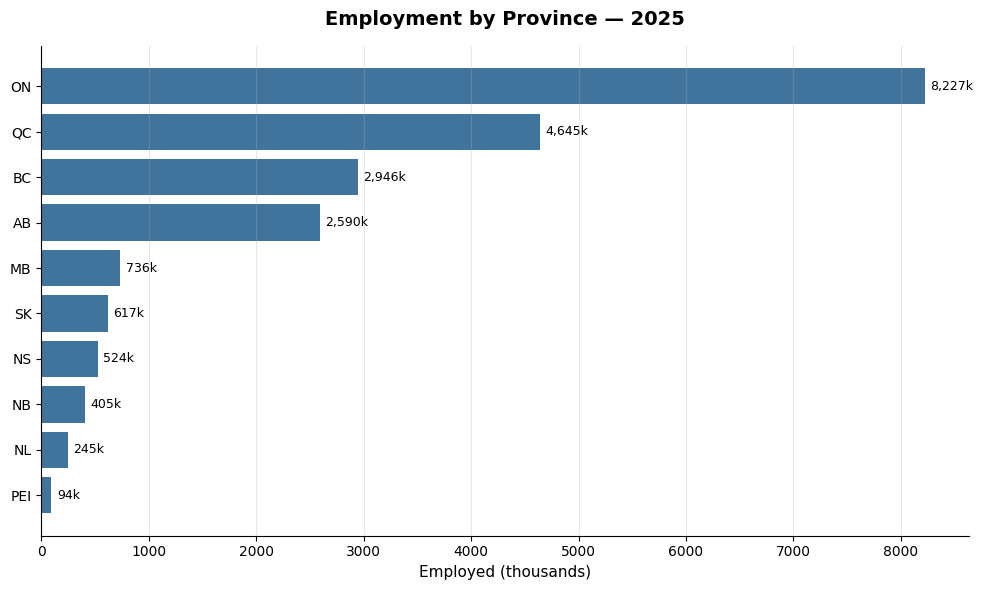

Chart saved!


In [28]:
# Get most recent year available
latest_year = df_employed['year'].max()

df_prov_latest = df_employed[
    (df_employed['year'] == latest_year) &
    (df_employed['industry'] == 'Total, all industries')
].groupby('geography')['value'].sum().sort_values(ascending=True)

# Shorten province names
prov_short = {
    'Ontario': 'ON', 'Quebec': 'QC', 'British Columbia': 'BC',
    'Alberta': 'AB', 'Manitoba': 'MB', 'Saskatchewan': 'SK',
    'Nova Scotia': 'NS', 'New Brunswick': 'NB',
    'Newfoundland and Labrador': 'NL', 'Prince Edward Island': 'PEI',
    'Northwest Territories': 'NWT', 'Yukon': 'YT', 'Nunavut': 'NU'
}
df_prov_latest.index = [prov_short.get(p, p) for p in df_prov_latest.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_prov_latest.index, df_prov_latest.values, color='#1F5C8B', alpha=0.85)

# Add value labels
for bar, val in zip(bars, df_prov_latest.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}k', va='center', fontsize=9)

ax.set_title(f'Employment by Province — {latest_year}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Employed (thousands)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../outputs/charts/02_employment_by_province.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

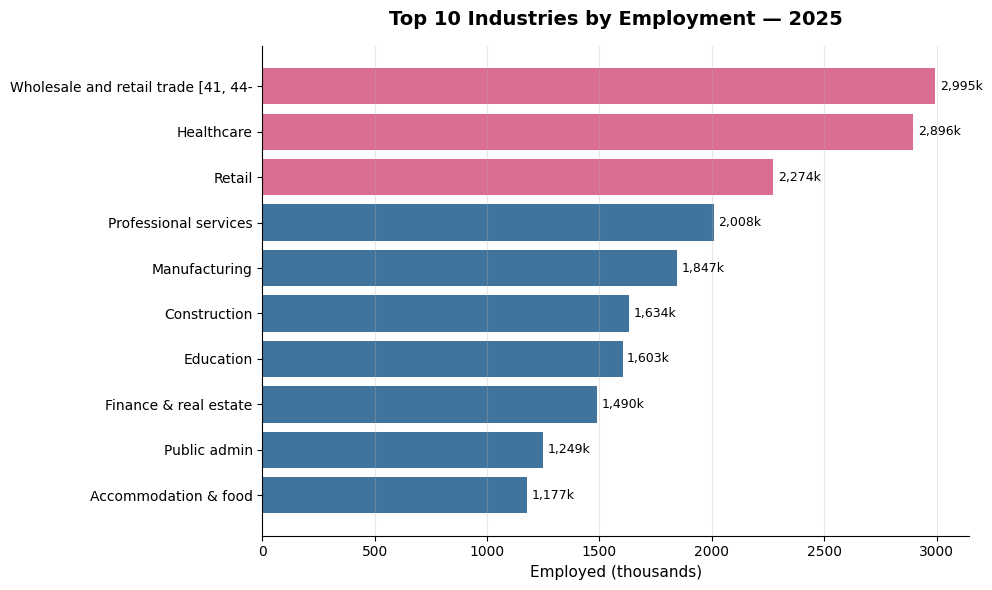

Chart saved!


In [29]:
# Filter out aggregate categories
exclude = ['Total, all industries', 'Goods-producing sector', 'Services-producing sector']

df_industry_latest = df_employed[
    (df_employed['year'] == latest_year) &
    (df_employed['geography'].isin(df_employed['geography'].unique())) &
    (~df_employed['industry'].isin(exclude))
].groupby('industry')['value'].sum().sort_values(ascending=True).tail(10)

# Shorten long industry names
def shorten(name):
    replacements = {
        'Educational services': 'Education',
        'Health care and social assistance': 'Healthcare',
        'Retail trade': 'Retail',
        'Construction': 'Construction',
        'Manufacturing': 'Manufacturing',
        'Professional, scientific and technical services': 'Professional services',
        'Public administration': 'Public admin',
        'Finance, insurance, real estate, rental and leasing': 'Finance & real estate',
        'Transportation and warehousing': 'Transport & warehousing',
        'Accommodation and food services': 'Accommodation & food',
        'Wholesale trade': 'Wholesale trade',
        'Information, culture and recreation': 'Info, culture & rec',
        'Agriculture': 'Agriculture',
        'Forestry, fishing, mining, quarrying, oil and gas': 'Forestry, mining & energy',
        'Utilities': 'Utilities',
        'Other services (except public administration)': 'Other services',
        'Business, building and other support services': 'Business support'
    }
    for k, v in replacements.items():
        if k in name:
            return v
    return name[:35]

df_industry_latest.index = [shorten(i) for i in df_industry_latest.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1F5C8B' if i < 7 else '#D4537E' for i in range(len(df_industry_latest))]
bars = ax.barh(df_industry_latest.index, df_industry_latest.values, color=colors, alpha=0.85)

for bar, val in zip(bars, df_industry_latest.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}k', va='center', fontsize=9)

ax.set_title(f'Top 10 Industries by Employment — {latest_year}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Employed (thousands)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../outputs/charts/03_top_industries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

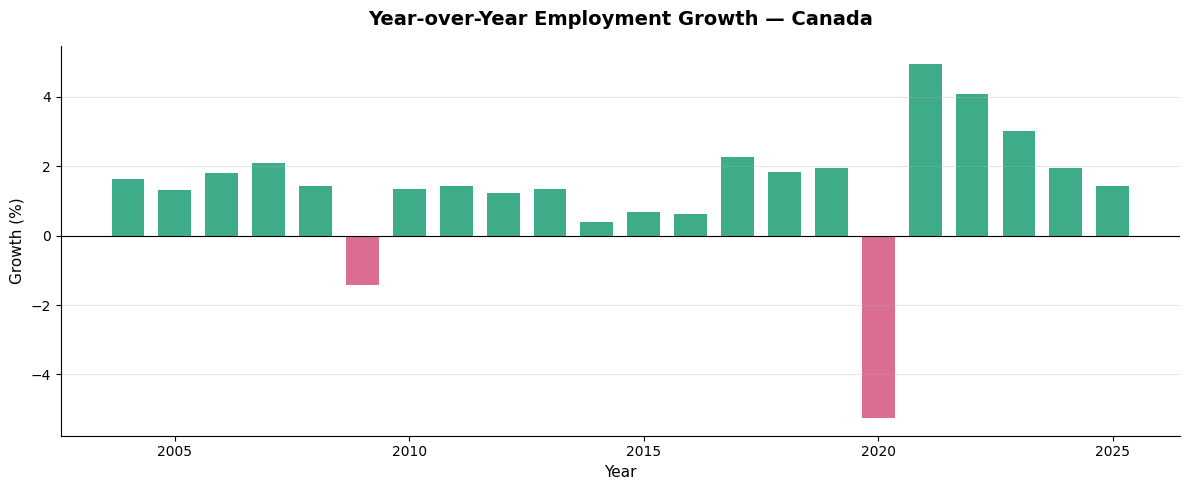

Chart saved!


In [30]:
df_yoy = df_industry[
    (df_industry['characteristic'] == 'Employment') &
    (df_industry['gender'] == 'Total - Gender') &
    (df_industry['age_group'] == '15 years and over') &
    (df_industry['geography'] == 'Canada') &
    (df_industry['industry'] == 'Total, all industries')
].copy().sort_values('year')

df_yoy['yoy_growth'] = df_yoy['value'].pct_change() * 100

# Focus on last 20 years
df_yoy = df_yoy[df_yoy['year'] >= 2004]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#D4537E' if x < 0 else '#1D9E75' for x in df_yoy['yoy_growth']]
ax.bar(df_yoy['year'], df_yoy['yoy_growth'], color=colors, alpha=0.85, width=0.7)
ax.axhline(0, color='black', linewidth=0.8)

ax.set_title('Year-over-Year Employment Growth — Canada', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Growth (%)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../outputs/charts/04_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [31]:
total_employed_latest = df_industry[
    (df_industry['characteristic'] == 'Employment') &
    (df_industry['gender'] == 'Total - Gender') &
    (df_industry['age_group'] == '15 years and over') &
    (df_industry['geography'] == 'Canada') &
    (df_industry['industry'] == 'Total, all industries') &
    (df_industry['year'] == latest_year)
]['value'].values[0]

covid_drop = df_yoy[df_yoy['year'] == 2020]['yoy_growth'].values[0]
recovery_growth = df_yoy[df_yoy['year'] == 2021]['yoy_growth'].values[0]

print("=" * 45)
print(f"KEY FINDINGS — Canadian Labour Market")
print("=" * 45)
print(f"Total employed ({latest_year}):  {total_employed_latest:,.1f}k")
print(f"COVID drop (2020):         {covid_drop:.1f}%")
print(f"Recovery growth (2021):    +{recovery_growth:.1f}%")
print(f"Years of data:             1976 – {latest_year}")
print(f"Provinces covered:         {df_employed['geography'].nunique()}")
print(f"Industries tracked:        {df_employed['industry'].nunique()}")
print("=" * 45)

KEY FINDINGS — Canadian Labour Market
Total employed (2025):  21,028.7k
COVID drop (2020):         -5.3%
Recovery growth (2021):    +5.0%
Years of data:             1976 – 2025
Provinces covered:         10
Industries tracked:        28


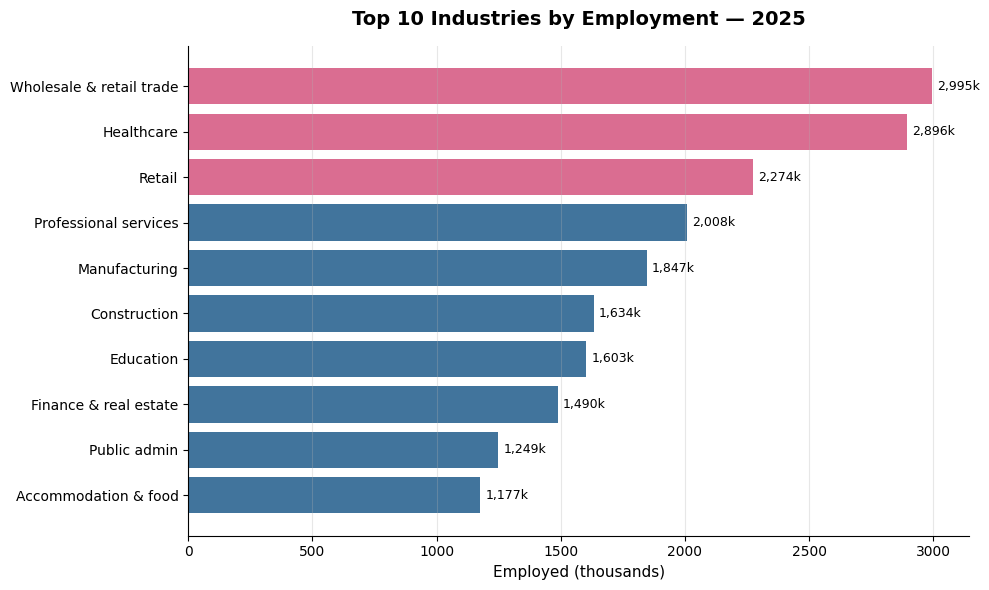

Chart 3 fixed and saved!


In [32]:
# Fix the truncated label in chart 3
df_industry_latest.index = [
    'Wholesale & retail trade' if 'Wholesale and retail' in i else i 
    for i in df_industry_latest.index
]

# Redraw and resave chart 3 cleanly
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1F5C8B' if i < 7 else '#D4537E' for i in range(len(df_industry_latest))]
bars = ax.barh(df_industry_latest.index, df_industry_latest.values, color=colors, alpha=0.85)

for bar, val in zip(bars, df_industry_latest.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}k', va='center', fontsize=9)

ax.set_title(f'Top 10 Industries by Employment — {latest_year}', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Employed (thousands)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/charts/03_top_industries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 fixed and saved!")

In [33]:
# Export 1: Employment by province by year (for Tableau map)
df_tableau_prov = df_employed[
    df_employed['industry'] == 'Total, all industries'
][['year', 'geography', 'value']].copy()
df_tableau_prov.columns = ['Year', 'Province', 'Employment_thousands']
df_tableau_prov.to_csv('../data/tableau_province.csv', index=False)

# Export 2: Employment by industry by year (for Tableau bar race)
exclude = ['Total, all industries', 'Goods-producing sector', 'Services-producing sector']
df_tableau_ind = df_employed[
    ~df_employed['industry'].isin(exclude)
][['year', 'industry', 'value']].copy()
df_tableau_ind.columns = ['Year', 'Industry', 'Employment_thousands']

# Apply short names
df_tableau_ind['Industry'] = df_tableau_ind['Industry'].apply(shorten)
df_tableau_ind.to_csv('../data/tableau_industry.csv', index=False)

# Export 3: YoY growth (for Tableau line chart)
df_yoy[['year', 'yoy_growth']].rename(
    columns={'year': 'Year', 'yoy_growth': 'YoY_Growth_Pct'}
).to_csv('../data/tableau_yoy.csv', index=False)

print("3 Tableau CSVs exported:")
print(f"  tableau_province.csv  — {len(df_tableau_prov):,} rows")
print(f"  tableau_industry.csv  — {len(df_tableau_ind):,} rows")
print(f"  tableau_yoy.csv       — {len(df_yoy)} rows")

3 Tableau CSVs exported:
  tableau_province.csv  — 500 rows
  tableau_industry.csv  — 11,311 rows
  tableau_yoy.csv       — 22 rows
